### Bloc 1 - Analyse exploratoire des données pour modélisation ML
1) Chargement du fichier
2) Fonction informative du dataset et affichage
3) Identification et selection des bâtiments qui ne sont pas dédié exclusivement à l'habitation



In [203]:
import pandas as pd
import matplotlib.pyplot as plt 
import missingno as msno

#### 1) Chargement du fichier à la racine du repertoire data


In [98]:
data = pd.read_csv('../data/2016_Building_Energy_Benchmarking.csv')

#### 2) Fonction informative du dataset et affichage

In [99]:
def info(df, name):
    print(f"Dataset: {name} - {df.shape[0]} rows {df.shape[1]} columns")
    profil = pd.DataFrame({ 
        'columns': df.columns.values,
        'non_null': df.notnull().sum().values,
        'nan': df.isna().sum().values,
        'nan %': (df.isna().sum() / len(df) * 100).values.round(0), 
        'unique':df.nunique().values,
        'types':df.dtypes.values,
        'types_size': df.apply(lambda col:(col.astype(str).str.len().max())).values
    })
    return profil
    

In [100]:
info(data, 'Seattle 2016')

Dataset: Seattle 2016 - 3376 rows 46 columns


,columns,non_null,nan,nan %,unique,types,types_size
0,OSEBuildingID,3376,0,0.0,3376,int64,5.0
1,DataYear,3376,0,0.0,1,int64,4.0
2,BuildingType,3376,0,0.0,8,str,20.0
3,PrimaryPropertyType,3376,0,0.0,24,str,27.0
4,PropertyName,3376,0,0.0,3362,str,72.0
5,Address,3376,0,0.0,3354,str,41.0
6,City,3376,0,0.0,1,str,7.0
7,State,3376,0,0.0,1,str,2.0
8,ZipCode,3360,16,0.0,55,float64,7.0
9,TaxParcelIdentificationNumber,3376,0,0.0,3268,str,25.0


In [101]:
pd.set_option("display.max_columns", None)
display(data.head())

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


#### 3) Identification et selection des bâtiments qui ne sont pas dédié exclusivement à l'habitation

In [102]:
# In identifie ce qu'il y a dans cette colonne afin de selectionner ce qui est pertinent
data['BuildingType'].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [103]:
# On instancie un nouveau df avec les batiments que l'on a selectionner dans cette colonne, et on affiche les infos pour constater le résultat
df_NonResidential = data[data['BuildingType'].isin(['NonResidential', 'Nonresidential COS', 'SPS-District K-12', 'Nonresidential WA', 'Campus'])]
info(df_NonResidential, 'Seattle 2016 NonResidential')

Dataset: Seattle 2016 NonResidential - 1668 rows 46 columns


,columns,non_null,nan,nan %,unique,types,types_size
0,OSEBuildingID,1668,0,0.0,1668,int64,5.0
1,DataYear,1668,0,0.0,1,int64,4.0
2,BuildingType,1668,0,0.0,5,str,18.0
3,PrimaryPropertyType,1668,0,0.0,22,str,27.0
4,PropertyName,1668,0,0.0,1664,str,72.0
5,Address,1668,0,0.0,1647,str,39.0
6,City,1668,0,0.0,1,str,7.0
7,State,1668,0,0.0,1,str,2.0
8,ZipCode,1652,16,1.0,48,float64,7.0
9,TaxParcelIdentificationNumber,1668,0,0.0,1587,str,25.0


#### 1) On se sert des colonnes utilitaires pour améliorer le dataset
- 'DefaultData'
- 'ComplianceStatus'
- 'OutLier'


In [165]:
# 'DefaultData'
# On identifie le contenu des colonnes
for column in ['DefaultData','ComplianceStatus', 'Outlier']:
    print (f"-" * 50)
    print(df_NonResidential[column].value_counts())

--------------------------------------------------
DefaultData
False    1580
True       88
Name: count, dtype: int64
--------------------------------------------------
ComplianceStatus
Compliant                       1548
Error - Correct Default Data      88
Non-Compliant                     18
Missing Data                      14
Name: count, dtype: int64
--------------------------------------------------
Outlier
Low outlier     15
High outlier     2
Name: count, dtype: int64


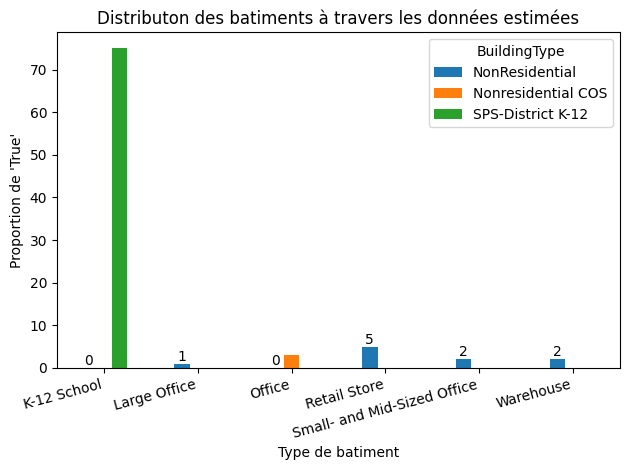

In [200]:
# On observe la repartition des données éstimées parmi les surfaces et les batiments, pour constater si il y a, ou non, concentration.
# On instancie le regroupement des batiments sur les données éstimées.
distri_dd = (
    df_NonResidential[df_NonResidential['DefaultData']== 1]
    .groupby(['PrimaryPropertyType','BuildingType'])['DefaultData']
    .count())

# Diagramme en barre
ax = distri_dd.unstack().plot(kind = 'bar')
ax.bar_label(ax.containers[0])

plt.title("Distributon des batiments à travers les données estimées")
plt.xlabel("Type de batiment")
plt.ylabel("Proportion de 'True'")
plt.xticks(rotation = 15, ha = 'right')
plt.tight_layout()
plt.show()

In [106]:
df_NonResidential['BuildingType'].value_counts()

BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

In [107]:
estimated_sps_total = (df_NonResidential[df_NonResidential['BuildingType'] == 'SPS-District K-12']['DefaultData'].mean() * 100).round(1)
print(f"La part des bâtiments scolaires dans les données éstimées est de : {estimated_sps_total} %")

La part des bâtiments scolaires dans les données éstimées est de : 76.5 %


La part des batiments scolaires est trop importantes pour pouvoir supprimer les entrées éstimées.  
Cela veut dire que si on elimine les données estimées du dataset, on supprimmera 76.5% des bâtiments scolaires.   
Par conséquent, la décision est de tout garder. Cette décisioin est aussi appuyée par les résultats marginaux des autres types de bâtiments.

In [108]:
# 'ComplianceStatus'
(df_NonResidential['ComplianceStatus'].value_counts(normalize = True)*100).round(1)

ComplianceStatus
Compliant                       92.8
Error - Correct Default Data     5.3
Non-Compliant                    1.1
Missing Data                     0.8
Name: proportion, dtype: float64

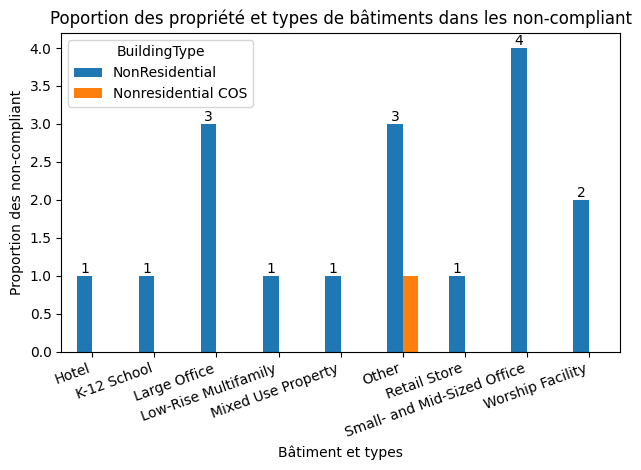

In [ ]:
distri_nc = (df_NonResidential[df_NonResidential['ComplianceStatus'] == 'Non-Compliant']
.groupby(['PrimaryPropertyType', 'BuildingType'])['ComplianceStatus']
.count())

ax = distri_nc.unstack().plot(kind = 'bar')
ax.bar_label(ax.containers[0])

plt.title('Poportion des propriété et types de bâtiments dans les non-compliant')
plt.xlabel('Bâtiment et types')
plt.ylabel('Proportion des non-compliant')
plt.xticks(rotation = 20, ha = 'right')
plt.tight_layout()
plt.show()


In [164]:
proportion_building = (df_NonResidential
    .groupby('PrimaryPropertyType')
    .apply(lambda x : (x['ComplianceStatus'] == 'Non-Compliant')
    .mean() * 100).round(1)
    .sort_values(ascending = False)
)

display(proportion_building)

PrimaryPropertyType
Low-Rise Multifamily           33.3
Worship Facility                2.8
Large Office                    1.7
Other                           1.6
Small- and Mid-Sized Office     1.4
Hotel                           1.3
Retail Store                    1.1
Mixed Use Property              0.9
K-12 School                     0.7
Distribution Center             0.0
Laboratory                      0.0
Hospital                        0.0
Office                          0.0
Medical Office                  0.0
Restaurant                      0.0
Residence Hall                  0.0
Refrigerated Warehouse          0.0
Self-Storage Facility           0.0
Senior Care Community           0.0
Supermarket / Grocery Store     0.0
University                      0.0
Warehouse                       0.0
dtype: float64

On constate que le nombre de *'compliant'* renvoie **92.8 %**.   
Cela indique que presque la totalité des renseignements ont été conforméments fournis par les structures.  
Les **5.3%** renvoie des erreurs alimentant la colonne DefaultData par des valeurs éstimées.
Les 'Non-Compliant'sont repartis de facon homogène, son total est marginal.   
**Il n'est pas necessaire d'aller plus loin et de filtrer via cette colonne.**

In [162]:
# Les outliers
df_NonResidential['Outlier'].value_counts()

Outlier
Low outlier     15
High outlier     2
Name: count, dtype: int64

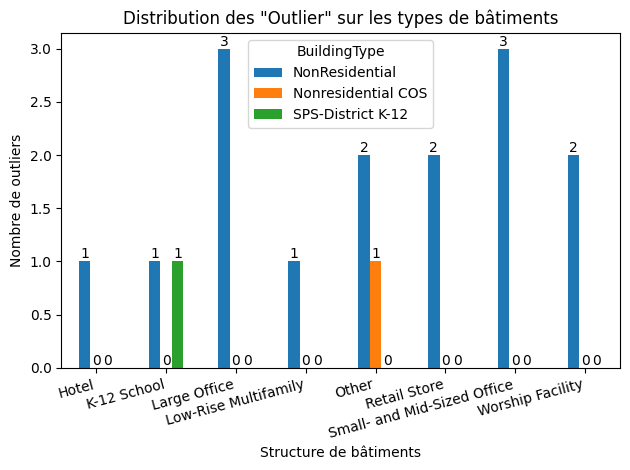

In [199]:
outlier = (df_NonResidential[df_NonResidential['Outlier'].notna()]
    .groupby(['PrimaryPropertyType', 'BuildingType'])['Outlier']
    .count()
    )

ax = outlier.unstack().fillna(0).plot(kind = 'bar')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution des "Outlier" sur les types de bâtiments')
plt.xlabel('Structure de bâtiments')
plt.ylabel('Nombre de outliers')
plt.xticks(rotation = 15, ha = 'right')
plt.tight_layout()
plt.show()


Les outliers sont peu nombreux et distribués de manières hétérogènes dans le type  
*'NonResidential'*.  
Dès lors, les outliers sont négligeables, il est préferable de les retirer afin d'améliorer la précision des modèles futurs.

## 4) 

<Axes: >

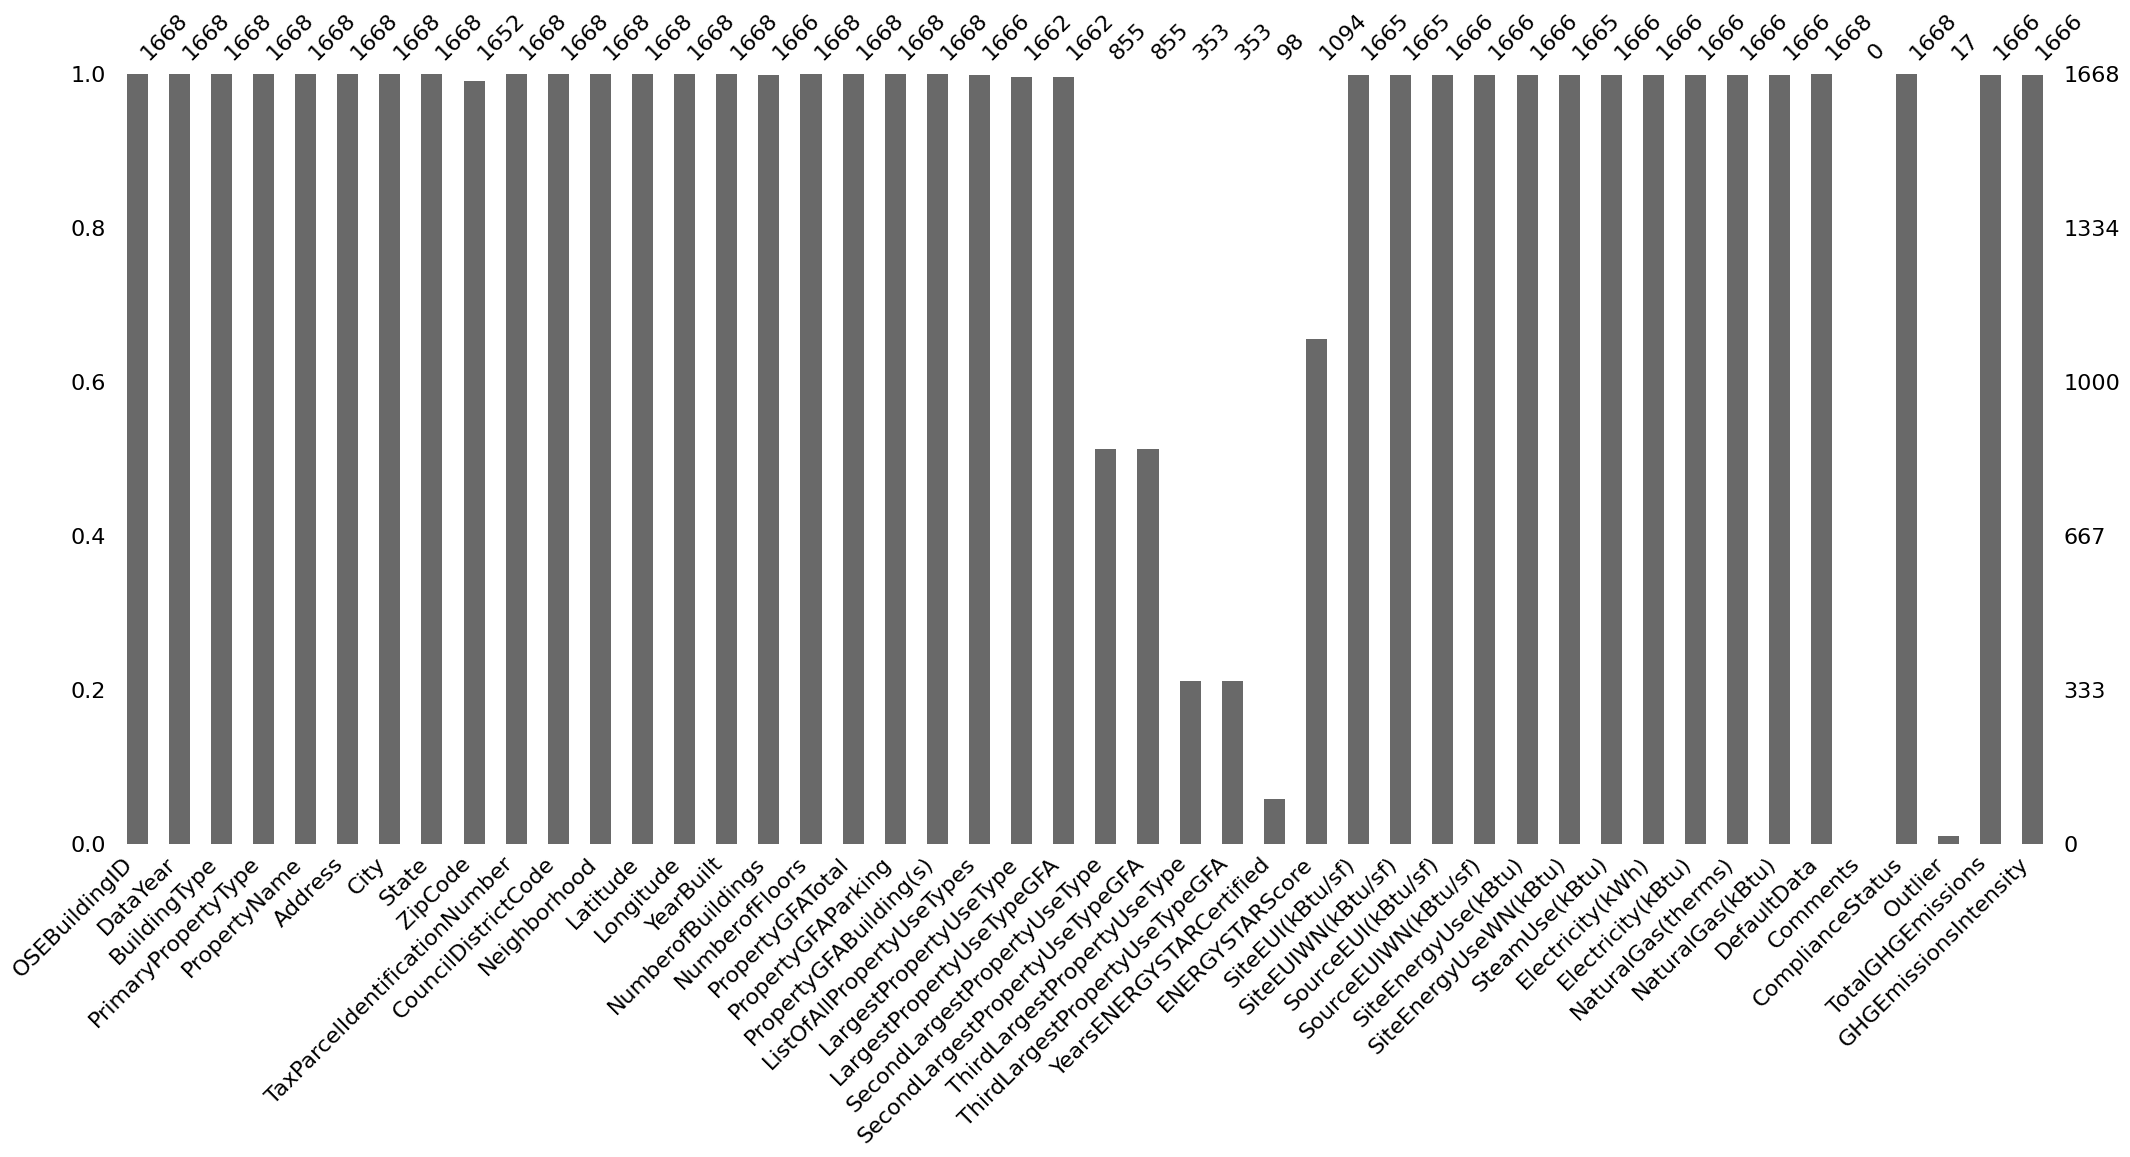

In [205]:
msno.bar(df_NonResidential)